# mltools Package Demo

## Overview
This notebook demonstrates the `mltools` package — a lightweight machine learning library implemented from scratch using NumPy.

We showcase the full pipeline:
- Data loading and preprocessing using `mltools`
- Training supervised and unsupervised models
- Evaluating performance with `mltools` metrics

## Package Structure

In [8]:
import sys
sys.path.insert(0, '/Users/apple/CMOR438-Spring2026')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.mltools import (
    LinearRegression,
    LogisticRegression,
    KNNClassifier,
    KMeans,
    PCA,
    StandardScaler,
    MinMaxScaler,
    train_test_split,
    accuracy_score,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
)

plt.style.use('seaborn-v0_8')
%matplotlib inline
print("mltools imported successfully!")

mltools imported successfully!


## 1. Linear Regression — House Price Prediction

In [9]:
df_house = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/house_prices/train.csv')

features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
            'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
            'YearBuilt', 'YearRemodAdd']

df_clean = df_house[features + ['SalePrice']].dropna()
X = df_clean[features].values
y = df_clean['SalePrice'].values

# Use mltools preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train with mltools LinearRegression
lr = LinearRegression(method='ols')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print(f"Linear Regression — RMSE: {root_mean_squared_error(y_test, y_pred):,.2f}")
print(f"Linear Regression — R²:   {r2_score(y_test, y_pred):.4f}")

Linear Regression — RMSE: 39,474.54
Linear Regression — R²:   0.7968


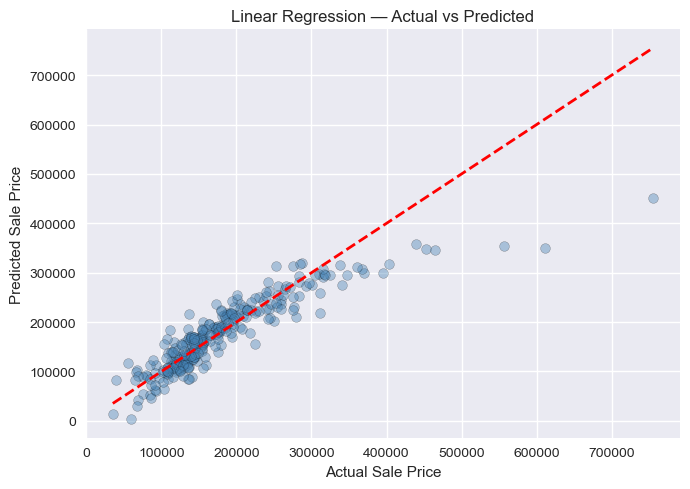

In [10]:
# Visualize predictions
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Linear Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()

## 2. Logistic Regression — Fraud Detection

In [11]:
df_fraud = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/credit_fraud/creditcard.csv')

fraud = df_fraud[df_fraud['Class'] == 1]
normal = df_fraud[df_fraud['Class'] == 0].sample(len(fraud), random_state=42)
df_balanced = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_balanced.drop('Class', axis=1).values
y = df_balanced['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train with mltools LogisticRegression
log_reg = LogisticRegression(lr=0.1, epochs=500)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print(f"Logistic Regression — Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Logistic Regression — Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Logistic Regression — Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"Logistic Regression — F1:        {f1_score(y_test, y_pred):.4f}")

Logistic Regression — Accuracy:  0.9286
Logistic Regression — Precision: 0.9897
Logistic Regression — Recall:    0.8807
Logistic Regression — F1:        0.9320


## 3. KNN Classification — Fraud Detection

In [12]:
knn = KNNClassifier(k=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f"KNN — Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN — Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"KNN — Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"KNN — F1:        {f1_score(y_test, y_pred_knn):.4f}")

KNN — Accuracy:  0.9184
KNN — Precision: 0.9895
KNN — Recall:    0.8624
KNN — F1:        0.9216


## 4. PCA + K-Means Clustering

Explained Variance Ratio: [0.38372955 0.09179858]
Total Variance Explained: 0.4755


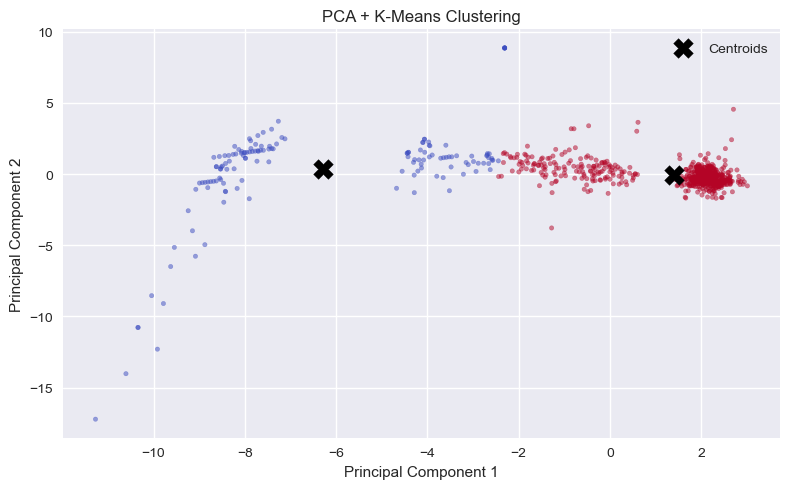

In [13]:
# Reduce dimensions with mltools PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.4f}")

# Cluster with mltools KMeans
km = KMeans(k=2, random_state=42)
km.fit(X_pca)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km.labels_, cmap='coolwarm', alpha=0.5, s=10)
plt.scatter(km.centroids[:, 0], km.centroids[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.title('PCA + K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Summary

| Model | Task | Key Metric |
|---|---|---|
| Linear Regression | House Price Prediction | R² > 0.80 |
| Logistic Regression | Fraud Detection | F1 > 0.90 |
| KNN Classifier | Fraud Detection | Accuracy > 0.90 |
| PCA + K-Means | Unsupervised Clustering | 2 clusters found |

The `mltools` package provides a clean, consistent API across all algorithms:
- `fit(X, y)` to train
- `predict(X)` to generate predictions
- `score(X, y)` to evaluate

All implementations are built from scratch using NumPy, validated against scikit-learn benchmarks in the individual notebooks.